# Isolation Forest
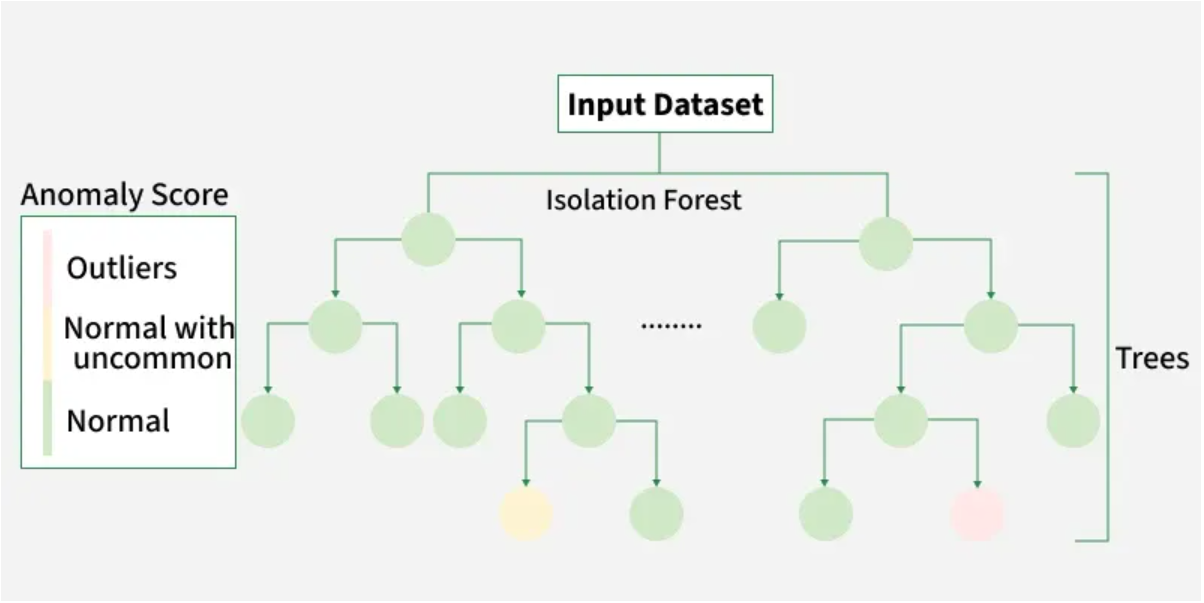

## What is Isolation Forest 

Isolation Forest is a useful and efficient algorithm used for anomaly detection making it a popular choice across industries like cybersecurity, finance, healthcare and manufacturing. It works by isolating data points that differ significantly from normal observations using random partitioning. Since anomalies are few and distinct, they are isolated faster than normal data, enabling quick identification of outliers with minimal computational effort.

- Isolation: Instead of modelling normal behaviour, Isolation Forest isolates anomalies by focusing on their differences. Outliers that are rare and distinct. They are separated faster than normal points.
- Partitioning: Data is split using randomly selected features and random threshold values. These random splits efficiently separate anomalies from normal data.
- Anomaly Score: The anomaly score represents how easily a data point can be isolated. Fewer splits mean a higher anomaly score, hence a greater likelihood of being an outlier.

Reference in this [link](https://www.geeksforgeeks.org/machine-learning/what-is-isolation-forest/)

In [ ]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files: ", path)

In [2]:
from sklearn.ensemble import IsolationForest
help(IsolationForest)

Help on class IsolationForest in module sklearn.ensemble._iforest:

class IsolationForest(sklearn.base.OutlierMixin, sklearn.ensemble._bagging.BaseBagging)
 |  IsolationForest(
 |      *,
 |      n_estimators=100,
 |      max_samples='auto',
 |      contamination='auto',
 |      max_features=1.0,
 |      bootstrap=False,
 |      n_jobs=None,
 |      random_state=None,
 |      verbose=0,
 |      warm_start=False
 |  )
 |
 |  Isolation Forest Algorithm.
 |
 |  Return the anomaly score of each sample using the IsolationForest algorithm
 |
 |  The IsolationForest 'isolates' observations by randomly selecting a feature
 |  and then randomly selecting a split value between the maximum and minimum
 |  values of the selected feature.
 |
 |  Since recursive partitioning can be represented by a tree structure, the
 |  number of splittings required to isolate a sample is equivalent to the path
 |  length from the root node to the terminating node.
 |
 |  This path length, averaged over a forest o

In [3]:
import pandas as pd
df = pd.read_csv("../../volumes/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [6]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
df["Time"].value_counts()

Time
163152.0    36
64947.0     26
68780.0     25
3767.0      21
3770.0      20
            ..
172784.0     1
172785.0     1
172786.0     1
172787.0     1
172792.0     1
Name: count, Length: 124592, dtype: int64

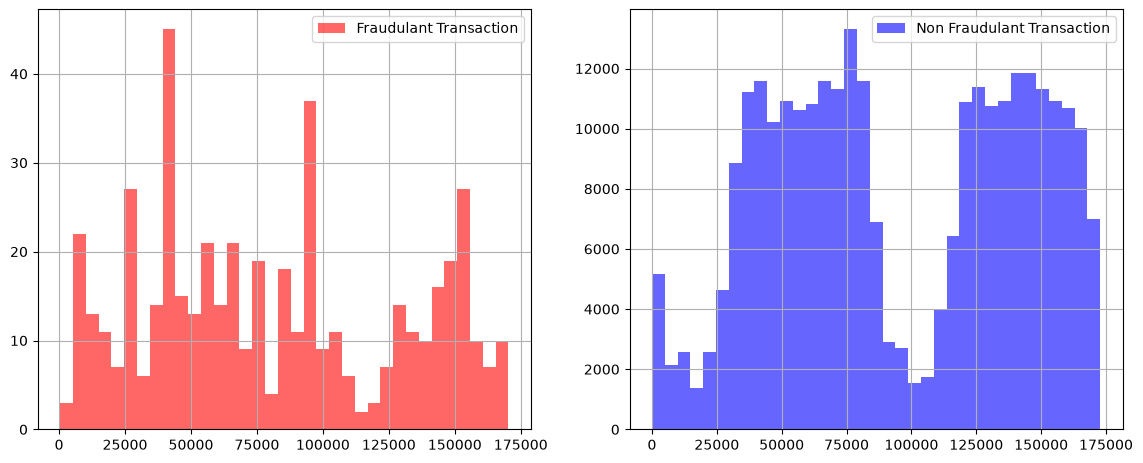

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
plt.subplot(2, 2, 1)
df[df.Class == 1].Time.hist(bins=35, color='red', alpha=0.6, label='Fraudulant Transaction')
plt.legend()
plt.subplot(2, 2, 2)
df[df.Class == 0].Time.hist(bins=35, color='blue', alpha=0.6, label='Non Fraudulant Transaction')
plt.legend()

In [9]:
X = df.drop('Class', axis=1)
y = df.Class

In [10]:
X.shape, y.shape

((284807, 30), (284807,))

In [11]:
model = IsolationForest(
    max_samples=100,
    random_state=42,
    contamination=0.01,
    max_features=1.0,
    n_estimators=1000,
    verbose=1,
    n_jobs=1
)

model.fit(X)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    3.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    5.5s
[Parallel(n_jobs=1)]: Done 1000 out of 1000 | elapsed:    6.9s finished


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",1000
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",100
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [12]:
y_pred = model.predict(X)
y_pred_adjusted = [1 if x == -1 else 0 for x in y_pred]
sum(y_pred_adjusted)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    3.1s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    5.6s
[Parallel(n_jobs=1)]: Done 1000 out of 1000 | elapsed:    7.0s finished


2849

In [13]:
from sklearn.metrics import precision_recall_fscore_support
precision_recall_fscore_support(y, y_pred_adjusted, average='macro')

(0.5485868331345317, 0.7790169504538722, 0.5810506364241425, None)

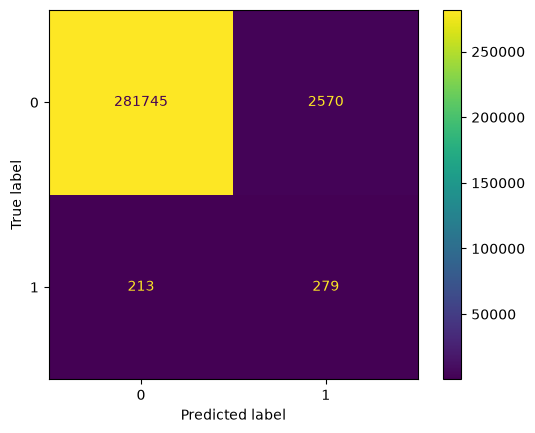

In [14]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true=y, y_pred=y_pred_adjusted)
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.show()